In [6]:
# Tải các file xml nhận diện từ OpenCV GitHub
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_smile.xml
# Tải file stop_data mẫu (giả định dùng tạm face cascade nếu bạn chưa có file stop riêng)
!cp haarcascade_frontalface_default.xml stop_data.xml

--2026-03-20 09:23:43--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haarcascade_frontalface_default.xml’

haarcascade_frontal 100%[===================>] 908.33K  --.-KB/s    in 0.007s  

2026-03-20 09:23:43 (136 MB/s) - ‘haarcascade_frontalface_default.xml’ saved [930127/930127]

--2026-03-20 09:23:43--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... co

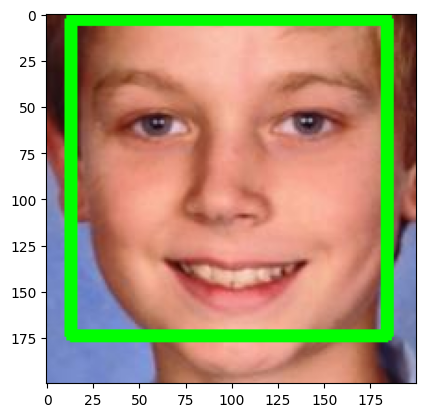

In [10]:
import cv2
import matplotlib.pyplot as An

# 1. Đọc ảnh hinh2.jpg
img = cv2.imread('hinh2.jpg')

# Kiểm tra nếu ảnh chưa được upload hoặc sai tên
if img is None:
    print("LỖI: Không tìm thấy file hinh2.jpg trong thư mục. Hãy kiểm tra lại!")
else:
    # 2. Chuyển đổi màu sắc
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Khởi tạo bộ nhận diện (Đảm bảo file xml đã có ở mục Files)
    stop_data = cv2.CascadeClassifier('/content/stop_data.xml')

    if stop_data.empty():
        print("LỖI: Không load được file stop_data.xml. Hãy kiểm tra đường dẫn!")
    else:
        # 4. Thực hiện nhận diện
        found = stop_data.detectMultiScale(img_gray, minSize=(20, 20))

        # 5. Vẽ khung hình chữ nhật nếu tìm thấy
        if len(found) != 0:
            for (x, y, width, height) in found:
                cv2.rectangle(img_rgb, (x, y), (x + width, y + height), (0, 255, 0), 5)
        else:
            print("Không tìm thấy đối tượng nào trong ảnh.")

        # 6. Hiển thị kết quả
        An.imshow(img_rgb)
        An.show()

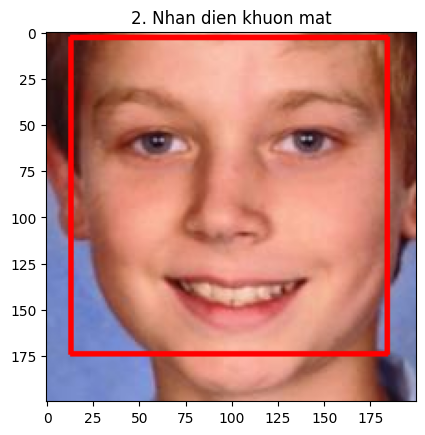

In [11]:
import cv2
import matplotlib.pyplot as An

# 1. Đọc ảnh và chuyển hệ màu
img = cv2.imread('hinh2.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Tải bộ nhận diện khuôn mặt
face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')

# 3. Phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

# 4. Vẽ khung đỏ cho mỗi khuôn mặt tìm thấy
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

# 5. Hiển thị
An.imshow(img_rgb)
An.title("2. Nhan dien khuon mat")
An.show()

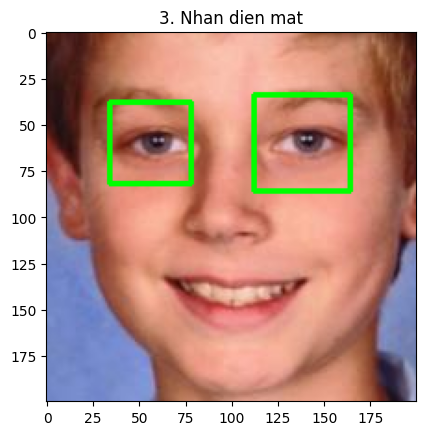

In [12]:
import cv2
import matplotlib.pyplot as Daniel

img = cv2.imread('hinh2.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('/content/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

for (x, y, w, h) in faces:
    # Cắt vùng khuôn mặt (Region of Interest)
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    # Tìm mắt trong vùng khuôn mặt
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

Daniel.imshow(img_rgb)
Daniel.title("3. Nhan dien mat")
Daniel.show()

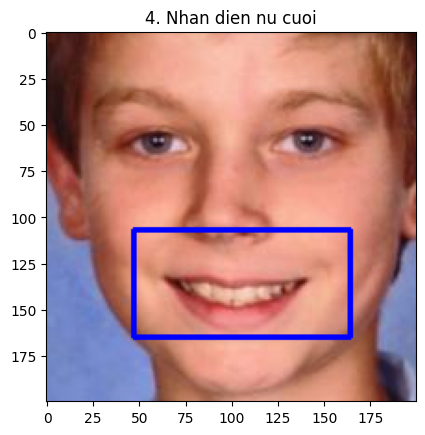

In [13]:
import cv2
import matplotlib.pyplot as Daniel

img = cv2.imread('hinh2.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier('/content/haarcascade_smile.xml')

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

for (x, y, w, h) in faces:
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    # Tìm nụ cười (chỉnh tham số 1.8 và 20 để tránh nhận diện nhầm)
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

Daniel.imshow(img_rgb)
Daniel.title("4. Nhan dien nu cuoi")
Daniel.show()